In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import ascii

In [ ]:
filename1 = "/content/drive/MyDrive/DESI/entropy/LRG_entropy_NGC_1.ecsv"
filename2 = "/content/drive/MyDrive/DESI/entropy/LRG_entropy_NGC_2.ecsv"

entropy_ngc1 = Table.read(filename1, format="ascii.ecsv")
entropy_ngc2 = Table.read(filename2, format="ascii.ecsv")

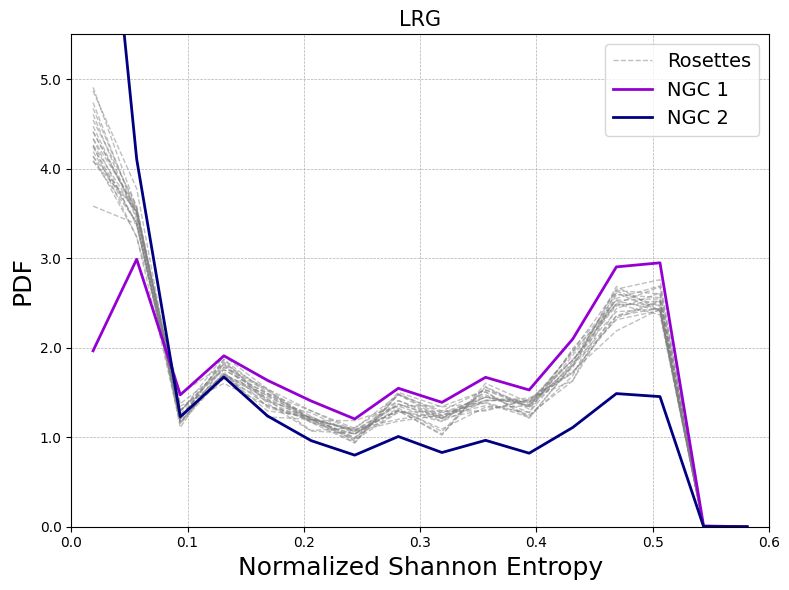

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

bins = 16

for i in range(20):
    file = f'/content/drive/MyDrive/DESI/entropy_rosette/LRG_entropy_rosette_{i}.ecsv'
    table = Table.read(file, format="ascii.ecsv")
    entropy_values = table['entropy']
    hist, bin_edges = np.histogram(entropy_values, bins=bins, range=(0, 0.6), density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    if i == 0:
        ax.plot(bin_centers, hist, linewidth=1, linestyle='--', color='grey', label='Rosettes',alpha=0.5)
    else:
        ax.plot(bin_centers, hist, linewidth=1, linestyle='--', color='grey',alpha=0.5)

hist, bin_edges = np.histogram(entropy_ngc1['entropy'], bins=bins, range=(0, 0.6), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.plot(bin_centers, hist, linewidth=2, color='darkviolet', label='NGC 1')

hist, bin_edges = np.histogram(entropy_ngc2['entropy'], bins=bins, range=(0, 0.6), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.plot(bin_centers, hist, linewidth=2, color='navy', label='NGC 2')

ax.set_xlabel(r"Normalized Shannon Entropy", fontsize=18)
ax.set_ylabel("PDF", fontsize=18)
ax.set_xlim(0, 0.6)
ax.set_ylim([0, 5.5])
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
ax.grid(True, linestyle='--', linewidth=0.5)

ax.legend(fontsize=14)
plt.title('LRG',size=15)
plt.tight_layout()
plt.savefig(f'PDF_LRG_NGC1_NGC2_Rosettes', dpi=300, bbox_inches='tight')
plt.show()